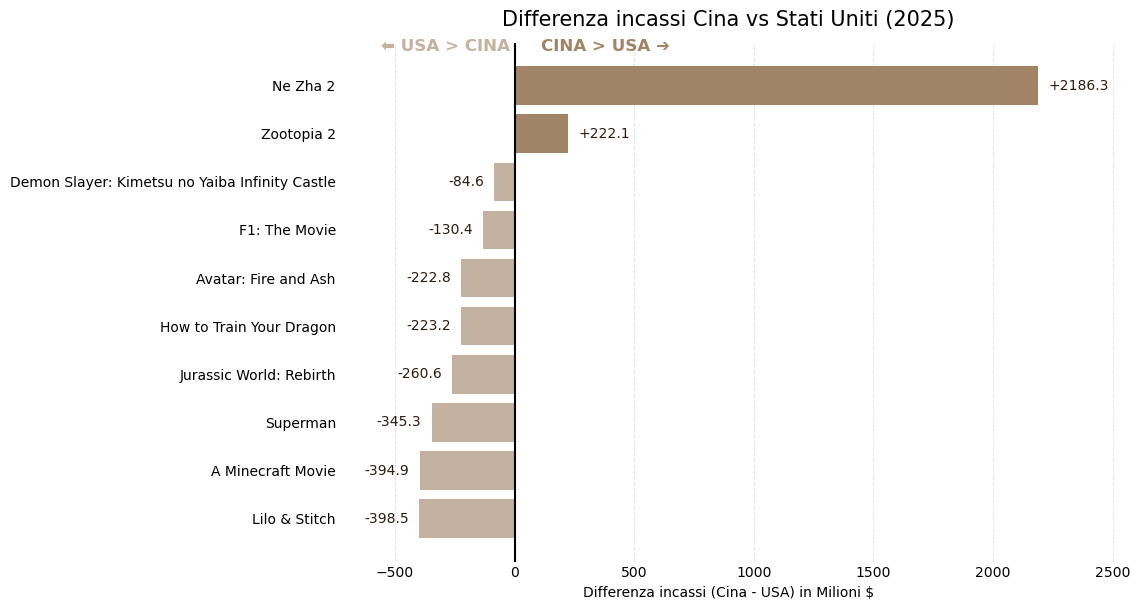

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

def parse_money(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip()
    if s.lower() in ["", "-", "nan", "none"]:
        return np.nan
    s = re.sub(r"[€$]", "", s)
    s = s.replace(" ", "")
    s = re.sub(r"[^0-9,\.]", "", s)
    if s == "":
        return np.nan
    if "," in s and "." in s:
        s = s.replace(".", "").replace(",", ".")
    else:
        if s.count(".") >= 2 and "," not in s:
            s = s.replace(".", "")
        elif s.count(",") >= 2 and "." not in s:
            s = s.replace(",", "")
        else:
            if "," in s and "." not in s:
                s = s.replace(".", "").replace(",", ".")
            elif "." in s and "," not in s:
                parts = s.split(".")
                if len(parts[-1]) == 3 and all(len(p) <= 3 for p in parts[:-1]):
                    s = "".join(parts)
    try:
        return float(s)
    except:
        return np.nan

raw = pd.read_csv("Nazione.csv")
raw.columns = raw.columns.str.strip()

header_row = raw.iloc[0].tolist()
cols = []
for i, c in enumerate(raw.columns):
    v = header_row[i]
    v = "" if pd.isna(v) else str(v).strip()
    cols.append(v if v != "" else c)

df = raw.iloc[1:].copy()
df.columns = cols
df = df.loc[:, ~df.columns.str.contains("^Unnamed")]

col_movie = df.columns[0]
df = df.rename(columns={col_movie: "Movie"})
df["Movie"] = df["Movie"].astype(str).str.strip()

for c in df.columns:
    if c != "Movie":
        df[c] = df[c].apply(parse_money)

df = df.fillna(0.0)

if "China" not in df.columns or "America" not in df.columns:
    raise ValueError("Nazione.csv deve contenere le colonne China e America")

df["Diff"] = (df["China"] - df["America"]) / 1e6

df = df.sort_values(by="Diff", ascending=True).reset_index(drop=True)

colore_unico = "#A18366"
colors = [colore_unico if v >= 0 else "#c4b19f" for v in df["Diff"]]

fig, ax = plt.subplots(figsize=(11.5, 6.2))

y = np.arange(len(df))
bars = ax.barh(y, df["Diff"], color=colors, edgecolor="none")

ax.axvline(0, color="black", linewidth=1.5)

ax.set_yticks(y)
ax.set_yticklabels(df["Movie"])
ax.set_xlabel("Differenza incassi (Cina - USA) in Milioni $")
ax.set_title("Differenza incassi Cina vs Stati Uniti (2025)", fontsize=15, pad=12)

ax.set_axisbelow(True)
ax.xaxis.grid(True, linestyle="--", alpha=0.3)

for b, v in zip(bars, df["Diff"]):
    if v >= 0:
        ax.text(v + abs(df["Diff"].max())*0.02, b.get_y() + b.get_height()/2, 
                f"+{v:.1f}", ha="left", va="center", fontsize=10, color="#2b1a10")
    else:
        ax.text(v - abs(df["Diff"].max())*0.02, b.get_y() + b.get_height()/2, 
                f"{v:.1f}", ha="right", va="center", fontsize=10, color="#2b1a10")

min_val, max_val = df["Diff"].min(), df["Diff"].max()
padding = max(abs(min_val), abs(max_val)) * 0.15
ax.set_xlim(min_val - padding, max_val + padding)

ax.text(max_val * 0.05, len(df) - 0.2, "CINA > USA ➔", ha="left", va="center", fontsize=12, color=colore_unico, fontweight="bold")
ax.text(min_val * 0.05, len(df) - 0.2, "⬅ USA > CINA", ha="right", va="center", fontsize=12, color="#c4b19f", fontweight="bold")

for spine in ax.spines.values():
    spine.set_visible(False)

ax.tick_params(length=0)

plt.tight_layout()
plt.show()